# Policy Gradient Basics

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement a simple policy gradient method
- Use rewards and baseline to reduce variance

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 2**.

---


## Lesson Brief

This lesson gives students their first look at **policy gradient** methods.

Instead of learning action values and choosing the best one, the agent learns parameters of the policy directly.

Why this matters: this is the conceptual doorway to actor-critic methods, PPO, and many modern RL systems.

Students should leave this lesson understanding the shift from value tables to direct policy optimization.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 7: Policy Gradient Methods"**:
[Watch on YouTube](https://www.youtube.com/watch?v=KHZVXao4qXs)

Why this pick:
- Explains the shift from value-based RL to direct policy optimization.
- Strong fit for students meeting policy gradients for the first time.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


# Policy Gradient Basics

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand policy gradient basics
- Apply concepts to real-world problems

## 🔗 Prerequisites

- ✅ Completed previous units
- ✅ Understanding of course concepts

---

## Real-World Context

This notebook demonstrates policy gradient basics with practical examples.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

"""
AIAT 123 - Policy Gradient Basics
Policy Gradient Basics
"""

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Show text or numbers in the cell output area under the code.
print("=" * 70)
# Show text or numbers in the cell output area under the code.
print("Policy Gradient Basics")
# Show text or numbers in the cell output area under the code.
print("=" * 70)

# Implementation here
# Show text or numbers in the cell output area under the code.
print("\n✅ Notebook ready for implementation!")


Policy Gradient Basics

✅ Notebook ready for implementation!


## 🌍 Real-World Worked Example — REINFORCE on CartPole

**Industry context:**
- Modern RL systems often use more advanced policy-gradient relatives such as PPO
- Boston Dynamics uses policy-gradient-style control methods in robotics research
- Robotic surgery systems can use policy optimization ideas for precise sequential decisions

We implement **REINFORCE** (the simplest policy gradient) on CartPole-v1.

Teaching note: REINFORCE is best presented here as an early member of the same family, not as a direct stand-in for RLHF systems.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Episode   0 | Avg reward: 16.0
Episode  50 | Avg reward: 20.1


Episode 100 | Avg reward: 42.6


Episode 150 | Avg reward: 94.5


Episode 200 | Avg reward: 158.1


Episode 250 | Avg reward: 285.4


Episode 300 | Avg reward: 283.6


Episode 350 | Avg reward: 381.9


Episode 400 | Avg reward: 461.6


Episode 450 | Avg reward: 386.6


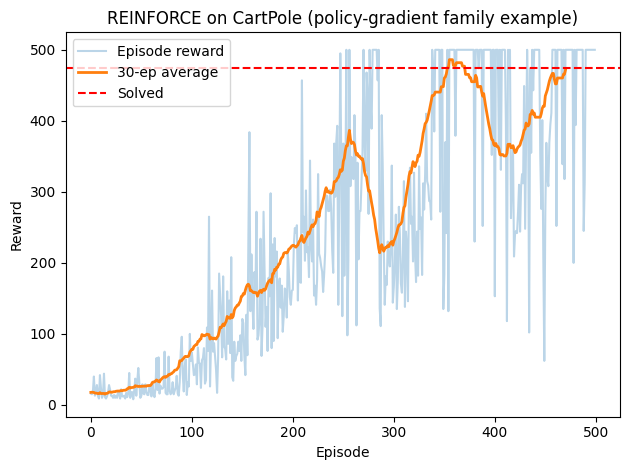

In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42)
# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')

# Class `PolicyNet` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class PolicyNet(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(4, 128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy  = PolicyNet()
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy.parameters(), lr=2e-3)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; ep_rewards = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(500):
    # Save a value in a name so the next lines can read it.
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(500):
        # Save a value in a name so the next lines can read it.
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        # Save a value in a name so the next lines can read it.
        dist   = torch.distributions.Categorical(probs)
        # Save a value in a name so the next lines can read it.
        action = dist.sample()
        # Add one new item to the end of a list (the list grows in place).
        log_probs.append(dist.log_prob(action))
        # Save a value in a name so the next lines can read it.
        obs, r, done, trunc, _ = env.step(action.item())
        # Add one new item to the end of a list (the list grows in place).
        rewards_ep.append(r)
        # If the condition is True, run the indented block under this line.
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    G = 0; returns = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in reversed(rewards_ep):
        # Save a value in a name so the next lines can read it.
        G = r + GAMMA*G; returns.insert(0, G)
    # Save a value in a name so the next lines can read it.
    returns = torch.tensor(returns).float()
    # Save a value in a name so the next lines can read it.
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    # Execute: opt.zero_grad(); loss.backward(); opt.step()
    opt.zero_grad(); loss.backward(); opt.step()
    # Add one new item to the end of a list (the list grows in place).
    ep_rewards.append(sum(rewards_ep))
    # If the condition is True, run the indented block under this line.
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

# Execute: env.close()
env.close()
# Save a value in a name so the next lines can read it.
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(ep_rewards, alpha=0.3, label="Episode reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(ma, lw=2, label="30-ep average")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(475, color='red', linestyle='--', label="Solved")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("REINFORCE on CartPole (policy-gradient family example)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.legend(); plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Papers:**
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

**State-of-the-Art:**
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control

## 📝 Summary

You learned **Policy Gradient** methods that directly optimize the policy without a value table. **Actor-Critic** combines a policy (actor) with a value estimator (critic) for lower variance. **PPO** is a later, more stable member of the same policy-optimization family and is widely used in modern RL practice.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


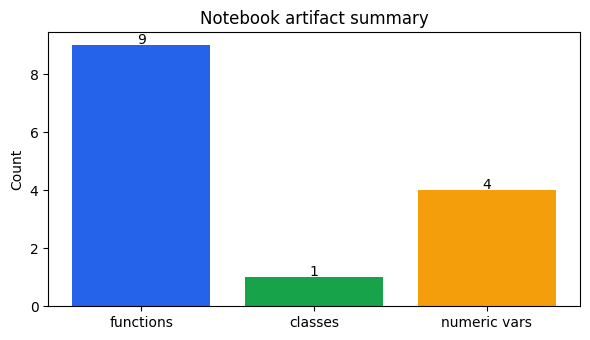

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Policy gradient methods learn the policy directly by increasing the probability of actions that lead to better returns.

**If students remember one idea:** Sometimes the goal is not to estimate a table of values first, but to optimize the policy itself.

**Quick check before moving on:**
- Can you explain why policy gradient methods work with action probabilities?
- Can you describe what signal tells the algorithm to increase or decrease an action probability?

**Bridge to the next step:** The next lesson returns to value estimation so students can compare direct policy learning with return-based estimation.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.
